# 09. Applying Unsupervised Learning Techniques (K-means Clustering)

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply K-means clustering to unlabeled data
- Understand unsupervised learning
- Identify clusters in data
- Evaluate clustering results
- Apply to real datasets

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 4, lesson 01 "K-Means Clustering" — the same algorithm and the same elbow/silhouette diagnostics, now on a full data-science dataset.

**Used later in:** Course 05 — Unit 4, lesson 10, which adds DBSCAN for the shapes k-means cannot find.

---

This notebook covers practical activities from **Course 05, Unit 4**:
- Applying unsupervised learning techniques (e.g., K-means clustering) on unlabeled data

---

## Introduction

**Unsupervised learning** discovers patterns in unlabeled data, with K-means clustering being a fundamental algorithm for grouping similar data points.


## 🎯 The case: Fisher's irises, and a metric that votes for the wrong answer

The 150 flowers you are about to cluster were measured by the botanist **Edgar Anderson**
in 1935 — fifty each of *Iris setosa*, *Iris versicolor* and *Iris virginica*, two of the
species picked in the same pasture on the same day, measured by the same person with the
same apparatus. R. A. Fisher used them in 1936 to introduce linear discriminant analysis,
and they have been the standard test case ever since.

They are also the standard *counter*-example, because of a botanical fact: **setosa
separates cleanly, and versicolor and virginica genuinely overlap** in these four
measurements. That is not a defect in the data. It is what those two species are like.

**What goes wrong without knowing the limits of your metric — and you will see it below in
one line.** With the species labels hidden, k-means with k=3 recovers setosa perfectly and
mixes the other two. Then the **silhouette score** is asked to choose k, and it answers
**k=2 (0.5818)** over k=3 (0.4599). The data contains three species. The metric prefers two,
because merging the two overlapping species produces rounder, better-separated blobs — and
roundness is what silhouette measures.

**On unlabelled data you would never find out.** That is the actual condition of
unsupervised learning: the metric is not measuring correctness, it is measuring geometry,
and there is no answer key to check it against.


## The Story

**BEFORE**: You know supervised learning but don't understand unsupervised learning and clustering.

**AFTER**: You'll learn unsupervised learning: K-means clustering, finding patterns in data without labels!

**Why this matters**: Applying Unsupervised Learning Techniques (K-means Clustering) is essential for building complete, professional data science solutions!

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Unlabeled data
- sklearn

**Outputs:** What you'll see when you run the cells

- Cluster labels
- Centroids
- Plots

---

In [1]:
# WHAT: Import K-Means tools and recap the algorithm's four steps.
# WHY: Unsupervised learning finds structure without labels - K-Means is its simplest, most-used member.

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("✅ Libraries imported!")
print("\nUnsupervised Learning: K-Means Clustering")
print("=" * 60)
print("""
Unsupervised learning = NO labels. We only have features X, and we ask
the algorithm to find structure on its own.

K-Means:
  1. Pick k cluster centers (centroids)
  2. Assign every point to its nearest centroid
  3. Move each centroid to the mean of its points
  4. Repeat 2-3 until assignments stop changing

Our data: Edgar Anderson's iris measurements (Fisher 1936) - 150 real flowers,
four measurements each. We HIDE the species labels, cluster blind, and only
at the end check what the algorithm recovered.
""")

✅ Libraries imported!

Unsupervised Learning: K-Means Clustering

Unsupervised learning = NO labels. We only have features X, and we ask
the algorithm to find structure on its own.

K-Means:
  1. Pick k cluster centers (centroids)
  2. Assign every point to its nearest centroid
  3. Move each centroid to the mean of its points
  4. Repeat 2-3 until assignments stop changing

Our data: Edgar Anderson's iris measurements (Fisher 1936) - 150 real flowers,
four measurements each. We HIDE the species labels, cluster blind, and only
at the end check what the algorithm recovered.



## Part 1: Cluster Unlabeled Data

We generate unlabeled 2-D data and let K-Means discover the groups.

Part 1: Fitting K-Means
------------------------------------------------------------
Data: 150 unlabeled flowers x 4 measurements
Measurements: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Cluster labels for the first 10 flowers: [1 1 1 1 1 1 1 1 1 1]
  cluster 0: 53 flowers
  cluster 1: 50 flowers
  cluster 2: 47 flowers

Centroids, converted back to centimetres:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0               5.80              2.67               4.37              1.41
1               5.01              3.43               1.46              0.25
2               6.78              3.10               5.51              1.97


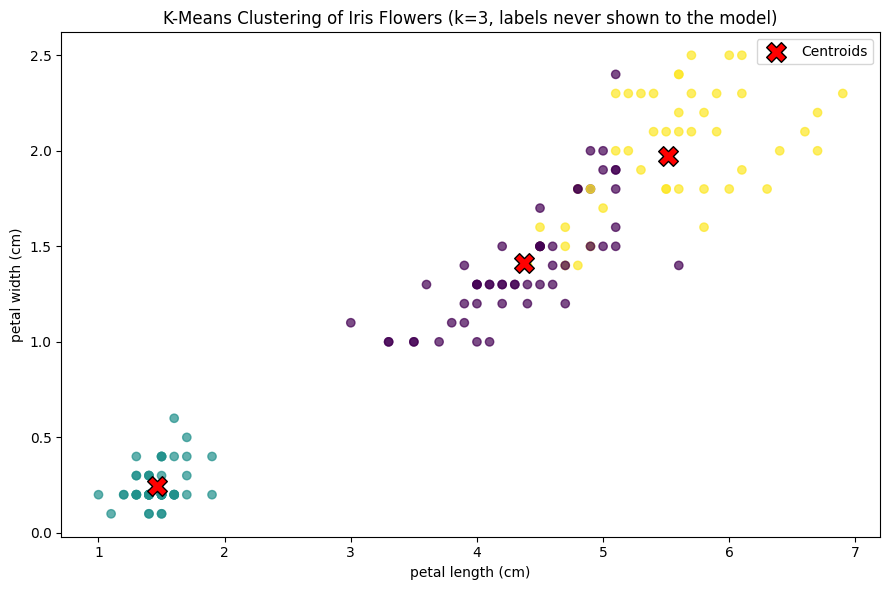

✓ Clusters and centroids plotted

What the clusters turned out to be (true species revealed AFTER clustering):
species  setosa  versicolor  virginica
cluster                               
0             0          39         14
1            50           0          0
2             0          11         36

💡 One species is recovered perfectly; the other two overlap and get mixed.
   That is real botany, not an algorithm failure - versicolor and virginica
   genuinely overlap in these four measurements.


In [2]:
# WHAT: Fit K-Means with k=3 on 150 real iris flowers (labels hidden) and plot clusters plus centroids.
# WHY: fit_predict returns a discovered label per point - structure found with zero supervision.

print("Part 1: Fitting K-Means")
print("-" * 60)

iris = load_iris()
X_raw = iris.data                      # 4 real measurements per flower, in cm
species = iris.target                  # the TRUE labels - we do not give these to K-Means
FEATURES = iris.feature_names

# Standardise: sepal length spans ~4-8 cm while petal width spans ~0.1-2.5 cm.
# Without scaling the big-range features dominate the distance calculation.
X = StandardScaler().fit_transform(X_raw)
print(f"Data: {X.shape[0]} unlabeled flowers x {X.shape[1]} measurements")
print(f"Measurements: {FEATURES}")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

print(f"\nCluster labels for the first 10 flowers: {labels[:10]}")
counts = np.bincount(labels)
for c, cnt in enumerate(counts):
    print(f"  cluster {c}: {cnt} flowers")
print("\nCentroids, converted back to centimetres:")
centroids_cm = StandardScaler().fit(X_raw).inverse_transform(kmeans.cluster_centers_)
print(pd.DataFrame(centroids_cm, columns=FEATURES).round(2).to_string())

# Plot on the two petal measurements - the pair that separates the species best.
plt.figure(figsize=(9, 6))
plt.scatter(X_raw[:, 2], X_raw[:, 3], c=labels, cmap='viridis', alpha=0.7)
plt.scatter(centroids_cm[:, 2], centroids_cm[:, 3],
            c='red', marker='X', s=200, edgecolors='black', label='Centroids')
plt.title('K-Means Clustering of Iris Flowers (k=3, labels never shown to the model)')
plt.xlabel(FEATURES[2])
plt.ylabel(FEATURES[3])
plt.legend()
plt.tight_layout()
plt.show()
print("✓ Clusters and centroids plotted")

# Now - and only now - we peek at the true species to see what was recovered.
crosstab = pd.crosstab(pd.Series(labels, name='cluster'),
                       pd.Series([iris.target_names[t] for t in species], name='species'))
print("\nWhat the clusters turned out to be (true species revealed AFTER clustering):")
print(crosstab.to_string())
print("\n💡 One species is recovered perfectly; the other two overlap and get mixed.")
print("   That is real botany, not an algorithm failure - versicolor and virginica")
print("   genuinely overlap in these four measurements.")

## Part 2: Choosing k — the Elbow Method

K-Means needs *you* to pick k. The elbow method plots inertia
(within-cluster sum of squared distances) for several k values — the
"elbow" where improvement slows is a good candidate.

Part 2: Elbow method
------------------------------------------------------------
  k=1: inertia =     600.0
  k=2: inertia =     222.4
  k=3: inertia =     139.8
  k=4: inertia =     114.1
  k=5: inertia =      90.9
  k=6: inertia =      81.5
  k=7: inertia =      72.6
  k=8: inertia =      62.5

Successive drops in inertia: [377.6, 82.5, 25.7, 23.2, 9.4, 8.9, 10.1]


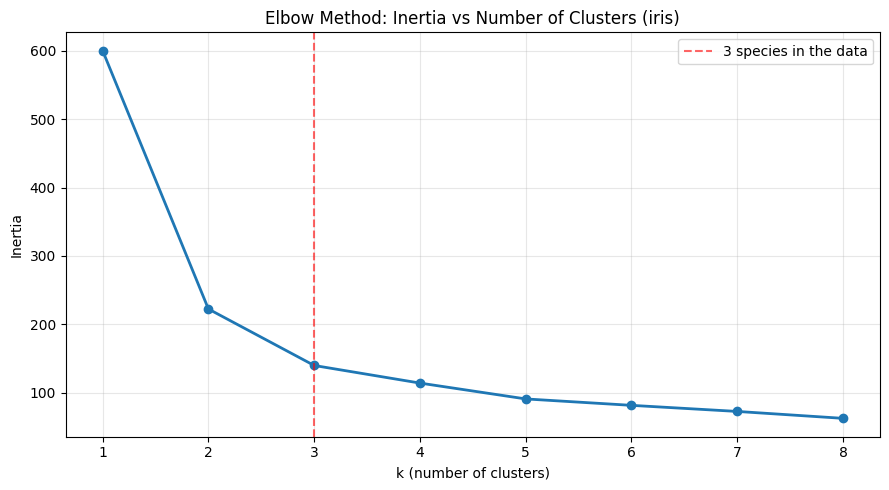

✓ Elbow plot drawn.
   The big drop is k=1→2 (378), then k=2→3 (83),
   then it flattens (26, 23, ...).
   On real data the elbow is a BEND, not a corner - here it argues for k=2 or 3.


In [3]:
# WHAT: Fit K-Means for k=1..8 and plot inertia (the elbow method).
# WHY: Inertia always falls as k grows - the ELBOW marks where extra clusters stop paying for themselves.

print("Part 2: Elbow method")
print("-" * 60)

k_values = range(1, 9)
inertias = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    print(f"  k={k}: inertia = {km.inertia_:9.1f}")

# The elbow is where successive drops in inertia stop being large.
drops = [inertias[i] - inertias[i + 1] for i in range(len(inertias) - 1)]
print(f"\nSuccessive drops in inertia: {[round(d, 1) for d in drops]}")

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertias, 'o-', linewidth=2)
plt.axvline(3, color='red', linestyle='--', alpha=0.6, label='3 species in the data')
plt.title('Elbow Method: Inertia vs Number of Clusters (iris)')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✓ Elbow plot drawn.")
print(f"   The big drop is k=1→2 ({drops[0]:.0f}), then k=2→3 ({drops[1]:.0f}),")
print(f"   then it flattens ({drops[2]:.0f}, {drops[3]:.0f}, ...).")
print("   On real data the elbow is a BEND, not a corner - here it argues for k=2 or 3.")

## Part 3: Evaluating Clusters — Silhouette Score

Inertia always decreases as k grows, so it can't pick k alone. The
**silhouette score** (-1 to +1, higher = better-separated clusters) can.

In [4]:
# WHAT: Compute silhouette scores for k=2..6.
# WHY: Silhouette checks cohesion vs separation per point - an independent second opinion on the choice of k.

print("Part 3: Silhouette scores")
print("-" * 60)

sil_scores = {}
for k in range(2, 7):
    km_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    sil_scores[k] = silhouette_score(X, km_labels)
    print(f"  k={k}: silhouette = {sil_scores[k]:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
n_species = len(np.unique(species))
print(f"\nBest silhouette score: k={best_k} ({sil_scores[best_k]:.4f})")
print(f"True number of species in the data: {n_species}")
if best_k != n_species:
    print("\n⚠️  The metric and the truth DISAGREE, and that is the lesson.")
    print(f"   Silhouette rewards well-separated blobs. Two of the {n_species} iris species")
    print("   overlap, so merging them into one cluster scores better - even though")
    print("   it is botanically wrong. Cluster-quality metrics measure geometry,")
    print("   not correctness. On unlabelled data you would never know the difference.")

Part 3: Silhouette scores
------------------------------------------------------------
  k=2: silhouette = 0.5818
  k=3: silhouette = 0.4599
  k=4: silhouette = 0.3869
  k=5: silhouette = 0.3459
  k=6: silhouette = 0.3171

Best silhouette score: k=2 (0.5818)
True number of species in the data: 3

⚠️  The metric and the truth DISAGREE, and that is the lesson.
   Silhouette rewards well-separated blobs. Two of the 3 iris species
   overlap, so merging them into one cluster scores better - even though
   it is botanically wrong. Cluster-quality metrics measure geometry,
   not correctness. On unlabelled data you would never know the difference.


## 💬 Discuss

Measured: the elbow's big drops are k=1→2 (**378**) then k=2→3 (**83**), then it flattens
(26, 23, …). Silhouette says **k=2 (0.5818)** and ranks k=3 at 0.4599. The truth is **3
species**, and the k=3 clustering recovered setosa 50/50 while splitting versicolor 39/11
and virginica 36/14.

1. Two respectable diagnostics, run on the same 150 flowers, and the one that gives a
   definite answer gives the wrong one. Write the sentence you would put in a report that
   is honest about both. What would you do next if you had no labels at all?
2. Silhouette prefers k=2 because merging two overlapping species yields rounder clusters.
   Name a *business* setting where that is the right answer anyway — where the geometric
   grouping is more useful than the true grouping.
3. The k=3 clustering put 14 virginica into a mostly-versicolor cluster. If these were
   customers rather than flowers, what would you do about the 14 — and what would you need
   to know before deciding they were misassigned rather than genuinely intermediate?


In [5]:
# WHAT: Print the summary with the silhouette-chosen k.
# WHY: The recap pulls its numbers from this run's variables, keeping the conclusions honest.

print("=" * 60)
print("Summary")
print("=" * 60)
print(f"""
What we actually did in this notebook, on {X.shape[0]} real iris flowers:
  1. Applied K-Means to {X.shape[0]} flowers with their species labels HIDDEN
     -> {len(counts)} clusters of sizes {[int(c) for c in counts]}
  2. Visualized the discovered clusters and their centers
  3. Chose k with the elbow method - the bend sits at k=2 or 3, not a sharp corner
  4. Evaluated cluster quality with the silhouette score
     -> best k by silhouette: k={best_k} (score {sil_scores[best_k]:.4f})
     -> the data actually contains {n_species} species

The honest conclusion: on real data, elbow and silhouette give you a RANGE,
not an answer. Domain knowledge decides; the metrics only narrow the field.

Next: Example 10 practices clustering further (K-Means vs DBSCAN).
""")
print("✅ Unsupervised learning with K-Means - complete!")

Summary

What we actually did in this notebook, on 150 real iris flowers:
  1. Applied K-Means to 150 flowers with their species labels HIDDEN
     -> 3 clusters of sizes [53, 50, 47]
  2. Visualized the discovered clusters and their centers
  3. Chose k with the elbow method - the bend sits at k=2 or 3, not a sharp corner
  4. Evaluated cluster quality with the silhouette score
     -> best k by silhouette: k=2 (score 0.5818)
     -> the data actually contains 3 species

The honest conclusion: on real data, elbow and silhouette give you a RANGE,
not an answer. Domain knowledge decides; the metrics only narrow the field.

Next: Example 10 practices clustering further (K-Means vs DBSCAN).

✅ Unsupervised learning with K-Means - complete!


## ⚠️ Where this breaks

- **k-means assumes clusters that are roughly spherical, similar in size, and similar in
  density.** Iris nearly satisfies that and still confuses two species. Elongated,
  crescent-shaped or nested clusters defeat it entirely — lesson 10 shows DBSCAN finding
  what k-means cannot.
- **It always returns exactly k clusters, including when there are none.** Feed it uniform
  noise and it will hand you k tidy, confident, meaningless groups with centroids.
- **Cluster-quality metrics measure geometry, not truth — and this notebook proves it.**
  Silhouette voted for k=2 on data containing 3 species. Inertia cannot pick k at all
  because it decreases monotonically. On unlabelled data there is no external check; that is
  the definition of the problem, not a gap in the tooling.
- **It is scale-dependent.** k-means minimises Euclidean distance, so a feature measured in
  a larger unit dominates. The iris measurements are all in centimetres, which quietly
  removes the problem here; on age-versus-fare (lesson 10) it does not.
- **The result depends on initialisation.** `k-means++` and multiple restarts (`n_init`)
  make this mostly invisible, but the algorithm converges to a local optimum, and different
  seeds can give different partitions on ambiguous data.
- **The assumption that must hold: "similar" means "close in Euclidean distance in your
  chosen feature space".** That is a modelling decision made when you picked the columns,
  and it is where most clustering projects actually go wrong — long before k is chosen.
- **Cheaper alternative:** if you already know what the groups should be, do not cluster —
  define the segments with rules and check them. Clustering is for when you genuinely do
  not know, and its output is a **hypothesis to be validated against something external**,
  never a finding on its own.


## 📚 References

1. MacQueen, J. (1967). *Some Methods for Classification and Analysis of Multivariate Observations*. Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability, 281-297.
2. Lloyd, S. P. (1982). *Least Squares Quantization in PCM*. IEEE Transactions on Information Theory, 28(2), 129-137.
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed., Ch. 12 (Unsupervised Learning). Springer. <https://www.statlearning.com>